In [5]:
!pip install xgboost
!pip install lightgbm


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import lightgbm as lgb

In [8]:
df = pd.read_csv("feature_engineered_dataset.csv")

In [9]:
y = df["units_sold"]

In [10]:
X = df.drop(["units_sold", "date", "store_id", "product_id"], axis=1)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# Clean data
X_train = X_train.select_dtypes(include=['number']).fillna(0)
X_test = X_test.select_dtypes(include=['number']).fillna(0)

# Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    n_jobs=-1
)

# Train
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [14]:
y_pred = xgb_model.predict(X_test)

In [15]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 0.9385848444336296


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

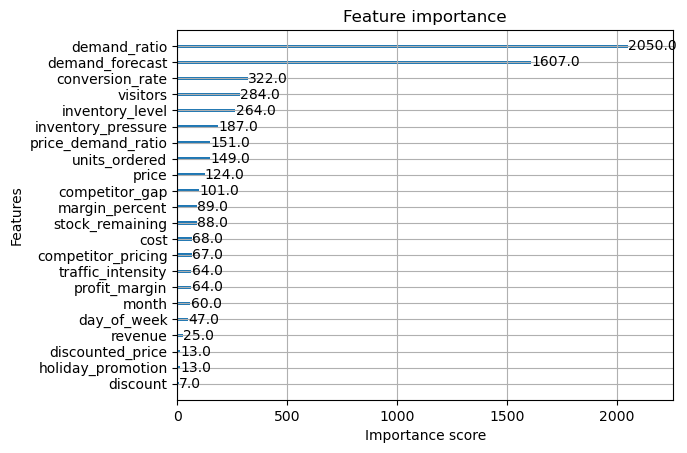

In [16]:
xgb.plot_importance(xgb_model)

In [18]:
# Convert categorical → numeric
X = pd.get_dummies(X, drop_first=True)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Align
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Train
xgb_model.fit(X_train, y_train)

# Predict on full dataset
df_encoded = pd.get_dummies(df.drop(["units_sold"], axis=1), drop_first=True)
df_encoded = df_encoded.reindex(columns=X_train.columns, fill_value=0)

df["predicted_demand"] = xgb_model.predict(df_encoded)

In [19]:
def optimize_price(row):
    if row["predicted_demand"] > row["units_sold"]:
        return row["price"] * 1.05
    else:
        return row["price"] * 0.95

In [21]:
def optimize_price(row):
    if row["predicted_demand"] > row["units_sold"]:
        return row["price"] * 1.05
    else:
        return row["price"] * 0.95

df["ml_price"] = df.apply(optimize_price, axis=1)

In [22]:
df["ml_revenue"] = df["ml_price"] * df["units_sold"]

In [25]:
print(df.columns)

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'inventory_level', 'units_sold', 'units_ordered', 'demand_forecast',
       'price', 'discount', 'weather_condition', 'holiday_promotion',
       'competitor_pricing', 'seasonality', 'visitors', 'cost',
       'profit_margin', 'margin_percent', 'demand_ratio', 'inventory_pressure',
       'competitor_gap', 'discounted_price', 'revenue', 'conversion_rate',
       'price_demand_ratio', 'stock_remaining', 'traffic_intensity',
       'day_of_week', 'month', 'is_weekend', 'predicted_demand', 'ml_price',
       'ml_revenue'],
      dtype='object')


In [26]:
df["baseline_revenue"] = df["price"] * df["units_sold"]

In [27]:
lift = (df["ml_revenue"].sum() - df["baseline_revenue"].sum()) / df["baseline_revenue"].sum() * 100
print("Lift:", lift)

Lift: -0.027671690691663628
